# Flagship End-to-End Analytics Project

## Python Analysis

This notebook is used for deeper exploratory analysis, customer and product pattern analysis, visualizations, and business insights using the cleaned project datasets.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

## Load Datasets

Load the Customers, Products, and Orders CSV files for Python analysis.

In [5]:
customers = pd.read_csv("../Data/05_Flagship_Customers.csv")
products = pd.read_csv("../Data/05_Flagship_Products.csv")
orders = pd.read_csv("../Data/05_Flagship_Orders.csv")

## Basic Dataset Inspection

Check dataset size, column names, data types, and sample records before deeper analysis.

In [6]:
print("Customers Shape:", customers.shape)
print("Products Shape:", products.shape)
print("Orders Shape:", orders.shape)

print("\nCustomers Columns:")
print(customers.columns.tolist())

print("\nProducts Columns:")
print(products.columns.tolist())

print("\nOrders Columns:")
print(orders.columns.tolist())

Customers Shape: (800, 7)
Products Shape: (150, 7)
Orders Shape: (3005, 14)

Customers Columns:
['Customer_ID', 'Signup_Date', 'City', 'Age_Band', 'Gender', 'Acquisition_Channel', 'Loyalty_Tier']

Products Columns:
['Product_ID', 'Category', 'Product_Type', 'Product_Name', 'List_Price', 'Unit_Cost', 'Supplier']

Orders Columns:
['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID', 'Product_ID', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Revenue', 'Cost', 'Profit', 'Order_Status', 'Payment_Mode', 'Sales_Channel']


## Data Types and Missing Values

Check column data types and identify missing values before cleaning and analysis.

In [7]:
print("Customers Data Types:")
print(customers.dtypes)

print("\nProducts Data Types:")
print(products.dtypes)

print("\nOrders Data Types:")
print(orders.dtypes)

print("\nCustomers Missing Values:")
print(customers.isnull().sum())

print("\nProducts Missing Values:")
print(products.isnull().sum())

print("\nOrders Missing Values:")
print(orders.isnull().sum())

Customers Data Types:
Customer_ID            str
Signup_Date            str
City                   str
Age_Band               str
Gender                 str
Acquisition_Channel    str
Loyalty_Tier           str
dtype: object

Products Data Types:
Product_ID          str
Category            str
Product_Type        str
Product_Name        str
List_Price      float64
Unit_Cost       float64
Supplier            str
dtype: object

Orders Data Types:
Order_ID             str
Order_Date           str
Ship_Date            str
Customer_ID          str
Product_ID           str
Quantity           int64
Unit_Price       float64
Discount_Pct     float64
Revenue          float64
Cost             float64
Profit           float64
Order_Status         str
Payment_Mode         str
Sales_Channel        str
dtype: object

Customers Missing Values:
Customer_ID            0
Signup_Date            0
City                   0
Age_Band               0
Gender                 0
Acquisition_Channel    0
Loyalty_Ti

## Duplicate Records Check

Check whether any dataset contains fully duplicated rows.

In [8]:
print("Customers Duplicate Rows:", customers.duplicated().sum())
print("Products Duplicate Rows:", products.duplicated().sum())
print("Orders Duplicate Rows:", orders.duplicated().sum())

Customers Duplicate Rows: 0
Products Duplicate Rows: 0
Orders Duplicate Rows: 5


## Remove Exact Duplicate Orders

Remove fully duplicated order rows while keeping the original raw DataFrame unchanged.

In [9]:
orders_clean = orders.drop_duplicates().copy()

print("Original Orders:", orders.shape[0])
print("Clean Orders:", orders_clean.shape[0])
print("Duplicates Removed:", orders.shape[0] - orders_clean.shape[0])

Original Orders: 3005
Clean Orders: 3000
Duplicates Removed: 5


## Convert Date Columns

Convert date columns from text/object format into proper datetime format for time-based analysis.

In [10]:
customers["Signup_Date"] = pd.to_datetime(customers["Signup_Date"])

orders_clean["Order_Date"] = pd.to_datetime(orders_clean["Order_Date"])
orders_clean["Ship_Date"] = pd.to_datetime(orders_clean["Ship_Date"])

In [11]:
print(customers[["Signup_Date"]].dtypes)
print(orders_clean[["Order_Date", "Ship_Date"]].dtypes)

Signup_Date    datetime64[us]
dtype: object
Order_Date    datetime64[us]
Ship_Date     datetime64[us]
dtype: object


## Merge Datasets

Combine Orders with Customers and Products to create one analysis-ready dataset.

In [12]:
df = orders_clean.merge(
    customers,
    on="Customer_ID",
    how="left"
).merge(
    products,
    on="Product_ID",
    how="left"
)

print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (3000, 26)


## Verify Merged Dataset

Check the merged dataset structure and confirm that customer and product details joined correctly.

In [13]:
print("Merged Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values After Merge:")
print(df.isnull().sum())

Merged Shape: (3000, 26)

First 5 Rows:


,Order_ID,Order_Date,Ship_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Discount_Pct,Revenue,Cost,...,Age_Band,Gender,Acquisition_Channel,Loyalty_Tier,Category,Product_Type,Product_Name,List_Price,Unit_Cost,Supplier
0,FO000001,2025-08-26,2025-08-28,FC00362,FP0005,2,936.51,0.00,1873.02,851.20,...,35-44,Female,Google Ads,Silver,Beauty,Serum,Pulse-005,936.51,425.60,Metro Wholesale
1,FO000002,2025-10-15,2025-10-17,FC00570,FP0098,4,8268.49,0.15,28112.87,21982.00,...,35-44,Male,Instagram,Bronze,Fashion,Shoes,Prime-098,8268.49,5495.50,Metro Wholesale
2,FO000003,2026-07-28,2026-07-30,FC00718,FP0017,4,1613.62,0.20,5163.58,4091.64,...,25-34,Male,Organic,Silver,Beauty,Serum,Prime-017,1613.62,1022.91,Prime Distribution
3,FO000004,2025-04-05,2025-04-06,FC00276,FP0125,4,3663.38,0.00,14653.52,10811.36,...,35-44,Female,Referral,Bronze,Beauty,Face Wash,Aster-125,3663.38,2702.84,Prime Distribution
4,FO000005,2024-04-03,2024-04-07,FC00202,FP0127,2,2634.40,0.00,5268.80,3081.02,...,25-34,Male,Organic,Bronze,Fashion,Shoes,Urban-127,2634.40,1540.51,Metro Wholesale



Missing Values After Merge:
Order_ID                 0
Order_Date               0
Ship_Date              163
Customer_ID              0
Product_ID               0
Quantity                 0
Unit_Price               0
Discount_Pct             0
Revenue                  0
Cost                     0
Profit                   0
Order_Status             0
Payment_Mode             0
Sales_Channel            0
Signup_Date              0
City                     0
Age_Band                 0
Gender                   0
Acquisition_Channel      0
Loyalty_Tier             0
Category                 0
Product_Type             0
Product_Name             0
List_Price               0
Unit_Cost                0
Supplier                 0
dtype: int64


## Feature Engineering

Create a few business-useful features for deeper analysis.

In [14]:
df["Order_Month"] = df["Order_Date"].dt.to_period("M").astype(str)

df["Profit_Margin_Pct"] = np.where(
    df["Revenue"] != 0,
    (df["Profit"] / df["Revenue"]) * 100,
    np.nan
)

customer_summary = (
    df.groupby("Customer_ID")
      .agg(
          Customer_Total_Revenue=("Revenue", "sum"),
          Customer_Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
)

customer_summary["Repeat_Customer"] = np.where(
    customer_summary["Customer_Total_Orders"] > 1,
    "Yes",
    "No"
)

display(customer_summary.head())

,Customer_ID,Customer_Total_Revenue,Customer_Total_Orders,Repeat_Customer
0,FC00001,31301.89,3,Yes
1,FC00002,8684.21,2,Yes
2,FC00003,48116.94,4,Yes
3,FC00004,30293.55,4,Yes
4,FC00005,94135.16,3,Yes


## Numeric Summary Statistics

Review the central tendency and range of important numeric business variables.

In [15]:
numeric_cols = [
    "Quantity",
    "Unit_Price",
    "Discount_Pct",
    "Revenue",
    "Cost",
    "Profit",
    "List_Price",
    "Unit_Cost"
]

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Quantity,3000.0,3.029667,1.419668,1.00,2.00,3.000,4.000,5.00
Unit_Price,3000.0,4692.694737,2656.757542,210.57,2384.81,4839.700,7057.580,8900.10
Discount_Pct,3000.0,0.085033,0.074875,0.00,0.00,0.100,0.150,0.20
Revenue,3000.0,12977.329320,10254.080768,168.46,4930.60,9687.540,19141.195,44500.50
Cost,3000.0,8797.706553,7109.932969,109.80,3331.64,6526.500,12781.900,34048.50
Profit,3000.0,4179.622767,3836.472036,18.87,1314.90,2892.285,6027.075,23520.95
List_Price,3000.0,4692.694737,2656.757542,210.57,2384.81,4839.700,7057.580,8900.10
Unit_Cost,3000.0,2917.818843,1752.506277,109.80,1405.27,2612.030,4371.900,6809.70


## Correlation Analysis

Analyze relationships between important numeric variables to identify useful patterns.

In [16]:
corr_cols = [
    "Quantity",
    "Unit_Price",
    "Discount_Pct",
    "Revenue",
    "Cost",
    "Profit",
    "List_Price",
    "Unit_Cost"
]

correlation_matrix = df[corr_cols].corr()

display(correlation_matrix)

,Quantity,Unit_Price,Discount_Pct,Revenue,Cost,Profit,List_Price,Unit_Cost
Quantity,1.000000,-0.011529,-0.004448,0.586645,0.571475,0.508893,-0.011529,-0.017012
Unit_Price,-0.011529,1.000000,0.001077,0.714784,0.709513,0.595562,1.000000,0.961510
Discount_Pct,-0.004448,0.001077,1.000000,-0.115251,-0.015657,-0.279026,0.001077,-0.006129
Revenue,0.586645,0.714784,-0.115251,1.000000,0.966856,0.880966,0.714784,0.680917
Cost,0.571475,0.709513,-0.015657,0.966856,1.000000,0.730953,0.709513,0.730930
Profit,0.508893,0.595562,-0.279026,0.880966,0.730953,1.000000,0.595562,0.465351
List_Price,-0.011529,1.000000,0.001077,0.714784,0.709513,0.595562,1.000000,0.961510
Unit_Cost,-0.017012,0.961510,-0.006129,0.680917,0.730930,0.465351,0.961510,1.000000


## Correlation Heatmap

Visualize correlations between important numeric variables to quickly identify strong relationships.

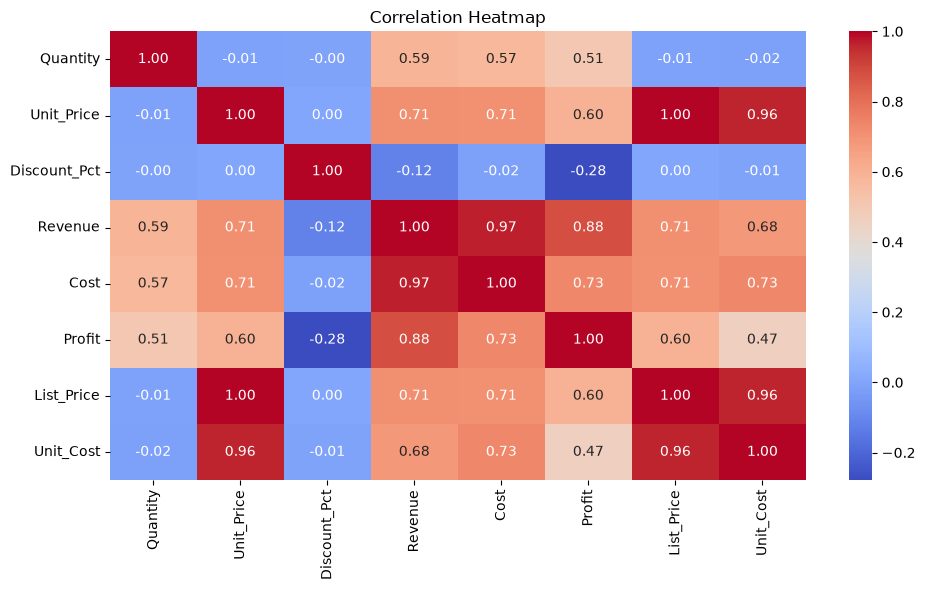

In [20]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Monthly Revenue Trend

Analyze how revenue changes month by month to identify growth, decline, and seasonality patterns.

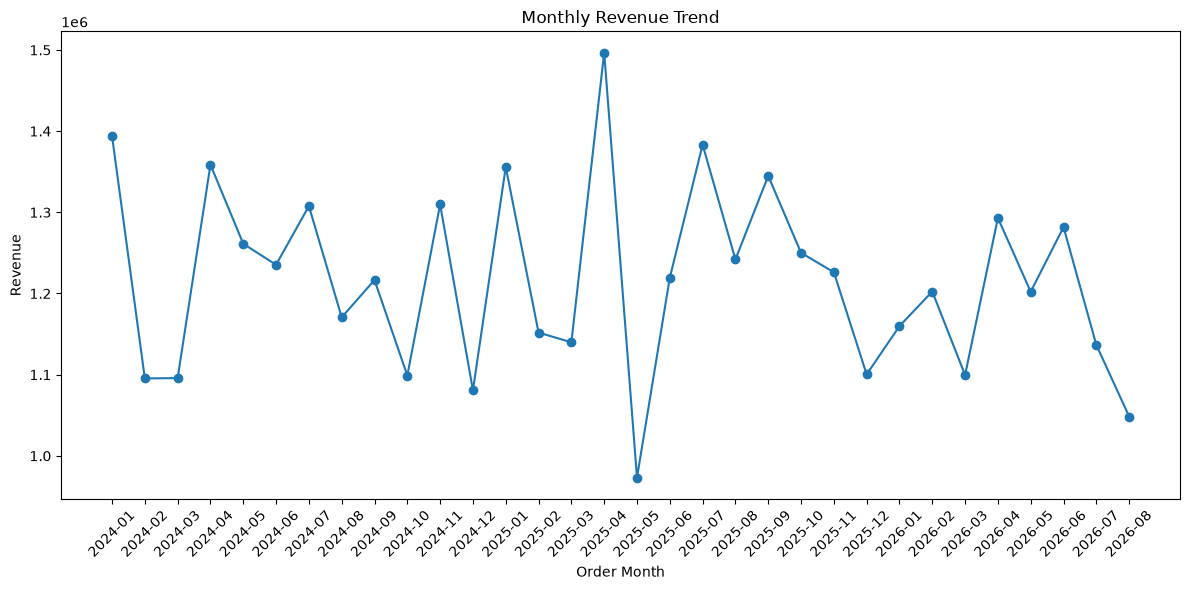

In [19]:
# Monthly Revenue Trend

monthly_revenue = (
    df.groupby("Order_Month", as_index=False)["Revenue"]
      .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Order_Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Order Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

# Save chart for portfolio / README
plt.savefig(
    "../Images/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Revenue by Category

Compare product categories based on total revenue contribution.

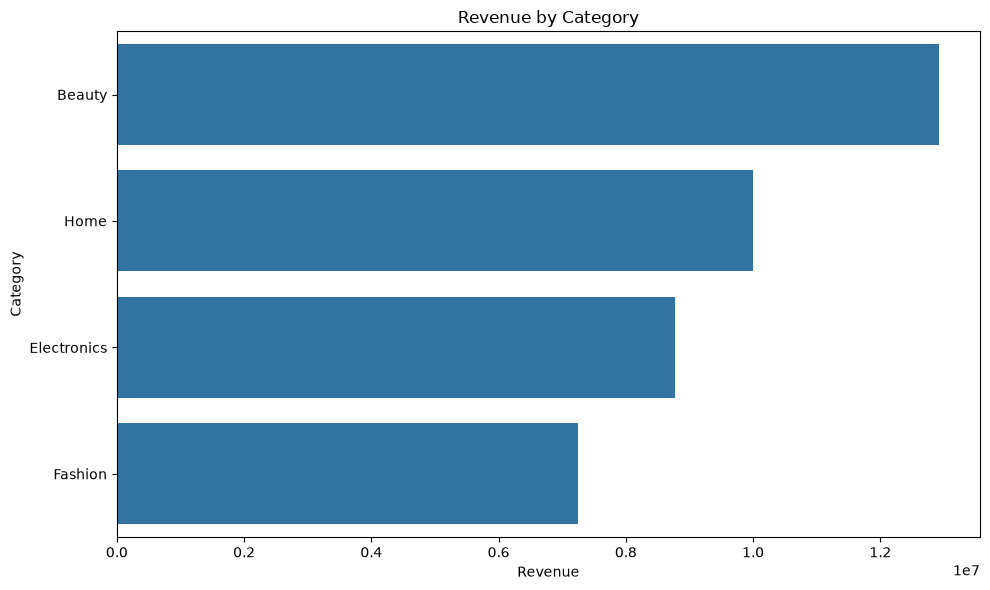

In [21]:
category_revenue = (
    df.groupby("Category", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue,
    x="Revenue",
    y="Category"
)

plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Top Products by Revenue

Identify the highest revenue-generating products.

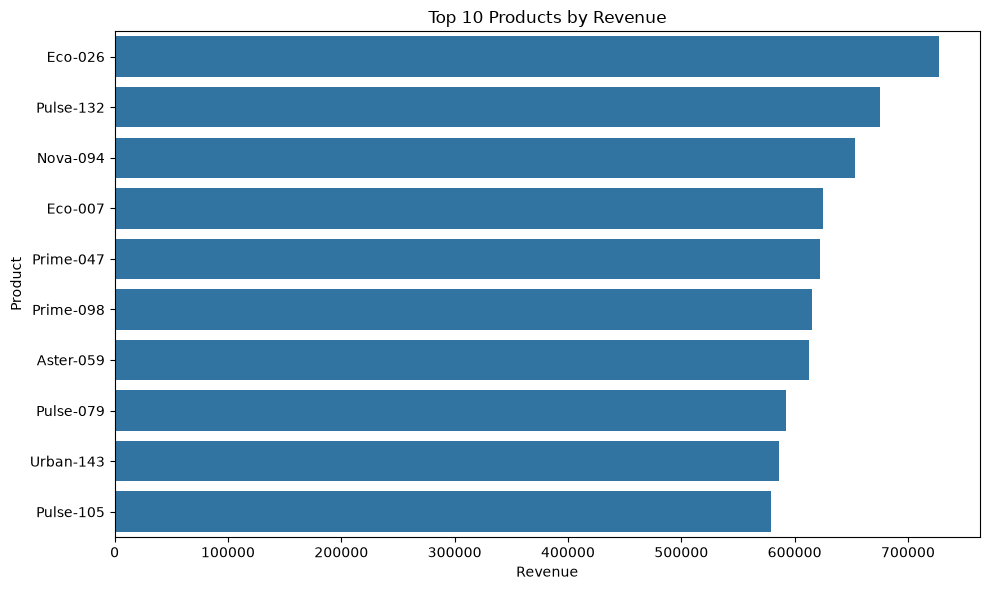

In [22]:
top_products = (
    df.groupby("Product_Name", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products,
    x="Revenue",
    y="Product_Name"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/top_10_products_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Revenue Distribution

Analyze how order revenue is distributed and identify whether most orders are low, medium, or high value.

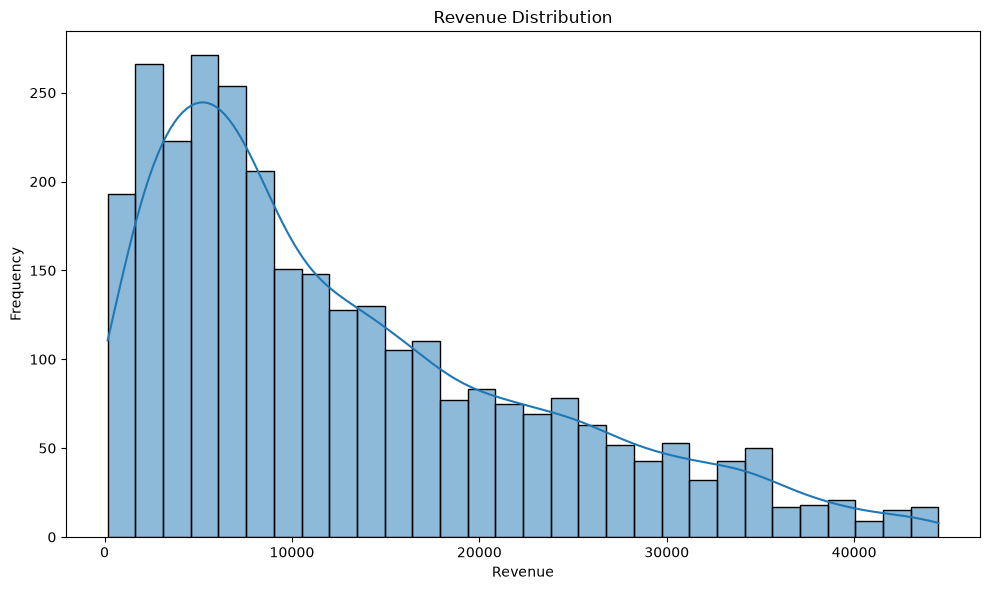

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Revenue",
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Profit Distribution and Outliers

Analyze the spread of profit values and identify unusually high or low-profit orders.

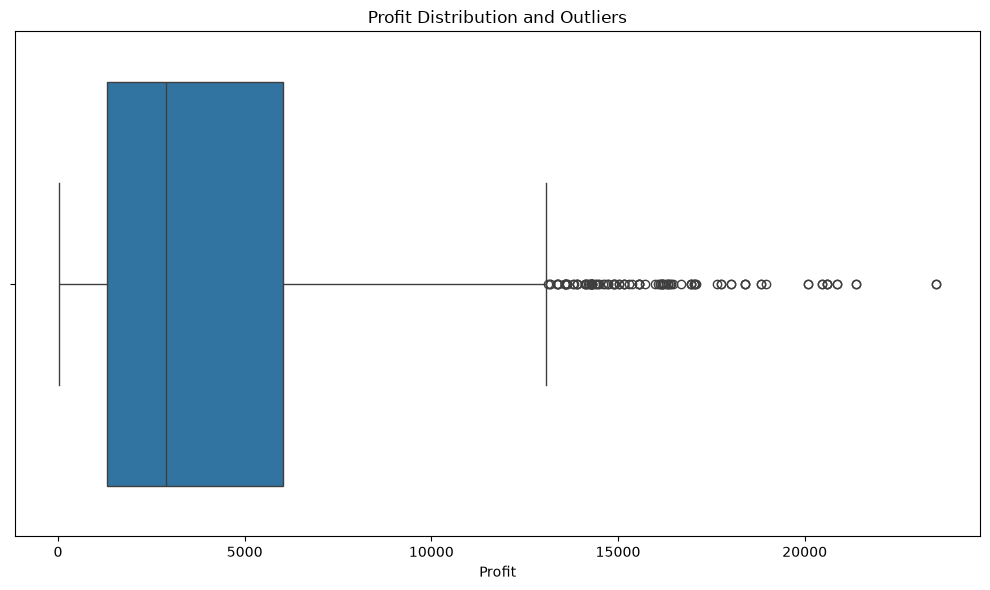

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Profit"
)

plt.title("Profit Distribution and Outliers")
plt.xlabel("Profit")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/profit_distribution_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Discount vs Profit

Analyze the relationship between discount percentage and profit to check whether higher discounts are associated with lower profitability.

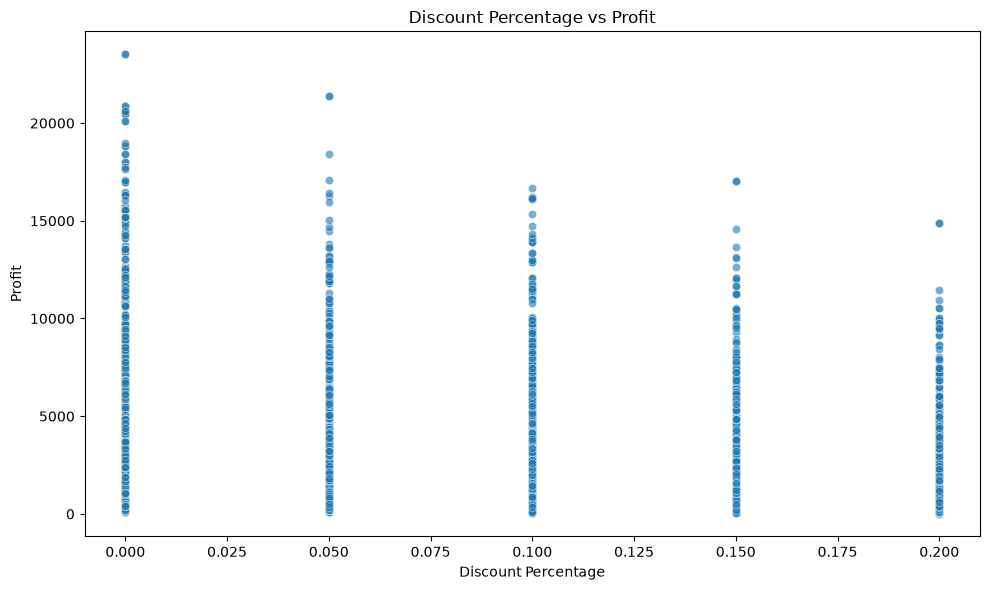

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount_Pct",
    y="Profit",
    alpha=0.6
)

plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/discount_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Customer Revenue Distribution

Analyze how customer spending is distributed and identify whether revenue is concentrated among a smaller group of customers.

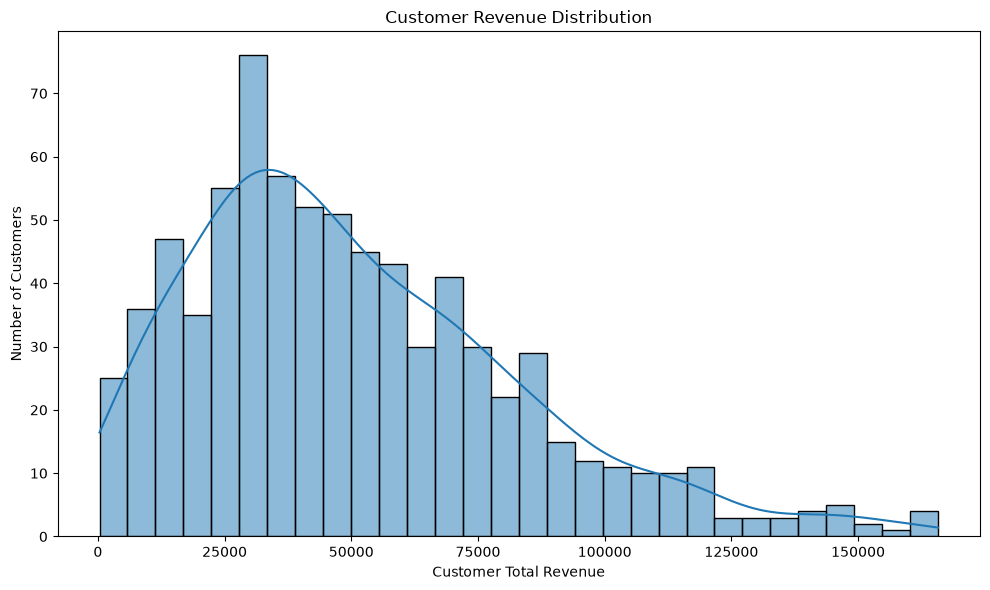

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=customer_summary,
    x="Customer_Total_Revenue",
    bins=30,
    kde=True
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Total Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/customer_revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Repeat vs One-Time Customers

Compare the number of repeat customers with one-time customers to understand customer retention behavior.

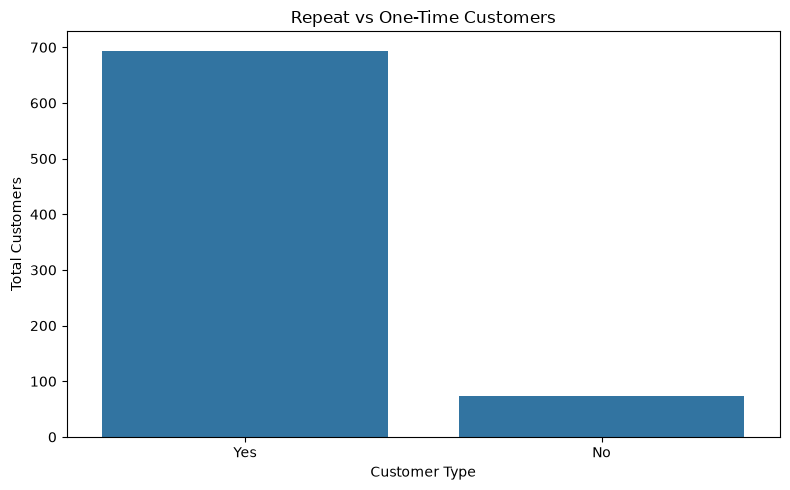

In [27]:
repeat_counts = (
    customer_summary["Repeat_Customer"]
    .value_counts()
    .reset_index()
)

repeat_counts.columns = ["Customer_Type", "Total_Customers"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=repeat_counts,
    x="Customer_Type",
    y="Total_Customers"
)

plt.title("Repeat vs One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Total Customers")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/repeat_vs_one_time_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Customer Segment Revenue

Compare customer value segments based on their total revenue contribution.

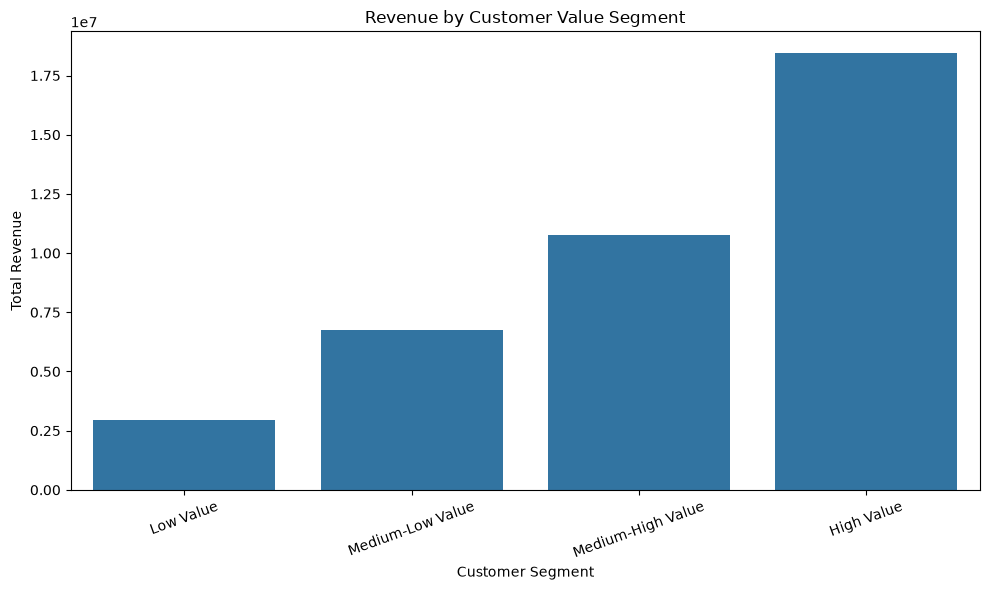

In [28]:
customer_segment = customer_summary.copy()

customer_segment["Value_Segment"] = pd.qcut(
    customer_segment["Customer_Total_Revenue"],
    q=4,
    labels=[
        "Low Value",
        "Medium-Low Value",
        "Medium-High Value",
        "High Value"
    ]
)

segment_revenue = (
    customer_segment
    .groupby("Value_Segment", observed=False)["Customer_Total_Revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_revenue,
    x="Value_Segment",
    y="Customer_Total_Revenue"
)

plt.title("Revenue by Customer Value Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=20)

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/revenue_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Sales Channel Profitability

Compare sales channels based on total profit to identify the most profitable selling channels.

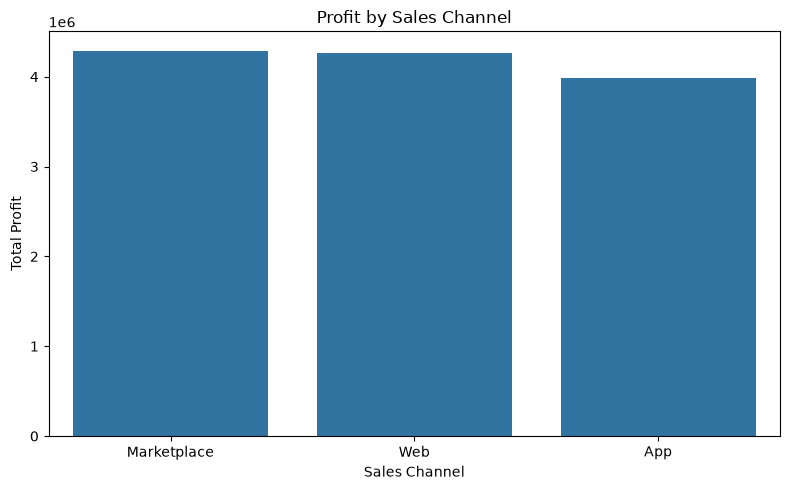

In [29]:
channel_profit = (
    df.groupby("Sales_Channel", as_index=False)["Profit"]
      .sum()
      .sort_values("Profit", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=channel_profit,
    x="Sales_Channel",
    y="Profit"
)

plt.title("Profit by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Profit")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/profit_by_sales_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Profit Margin by Category

Compare product categories based on profit margin to identify which categories are more efficient at generating profit.

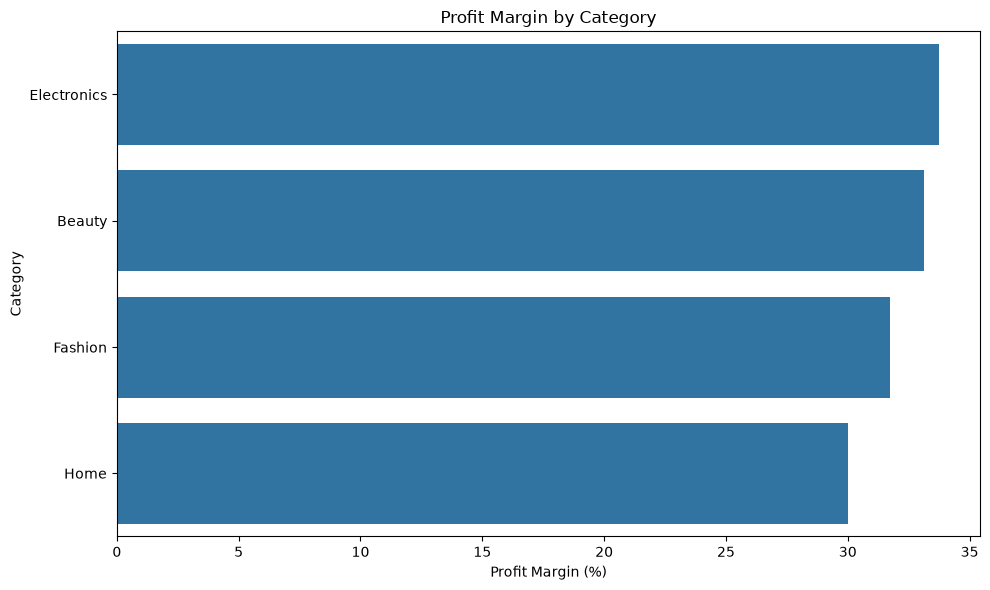

In [30]:
category_margin = (
    df.groupby("Category", as_index=False)
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

category_margin["Profit_Margin_Pct"] = (
    category_margin["Total_Profit"]
    / category_margin["Total_Revenue"]
) * 100

category_margin = category_margin.sort_values(
    "Profit_Margin_Pct",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_margin,
    x="Profit_Margin_Pct",
    y="Category"
)

plt.title("Profit Margin by Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Category")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/profit_margin_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Revenue vs Profit

Analyze the relationship between order revenue and profit to understand how strongly higher-value orders contribute to profitability.

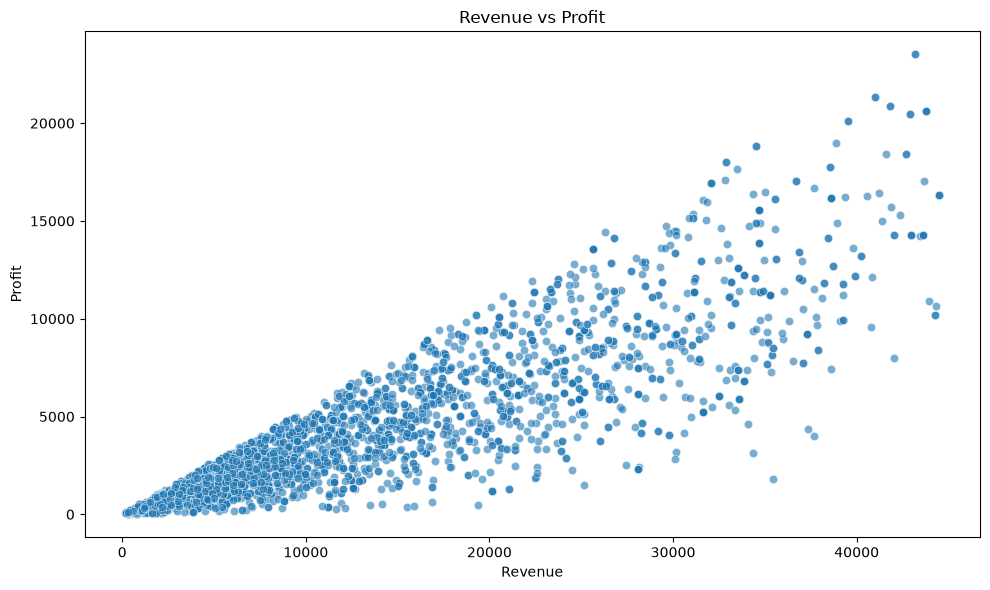

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Revenue",
    y="Profit",
    alpha=0.6
)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/revenue_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Order Quantity Distribution

Analyze how product quantity is distributed across orders to understand typical purchase size.

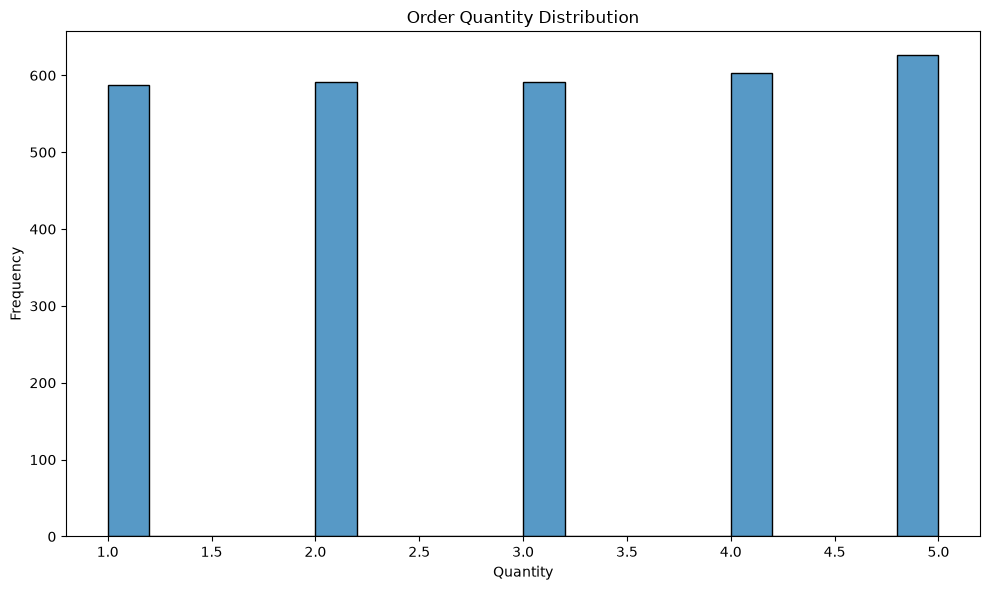

In [32]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Quantity",
    bins=20,
    kde=False
)

plt.title("Order Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/order_quantity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Customer Order Frequency Distribution

Analyze how many orders customers typically place to understand purchasing frequency and repeat behavior.

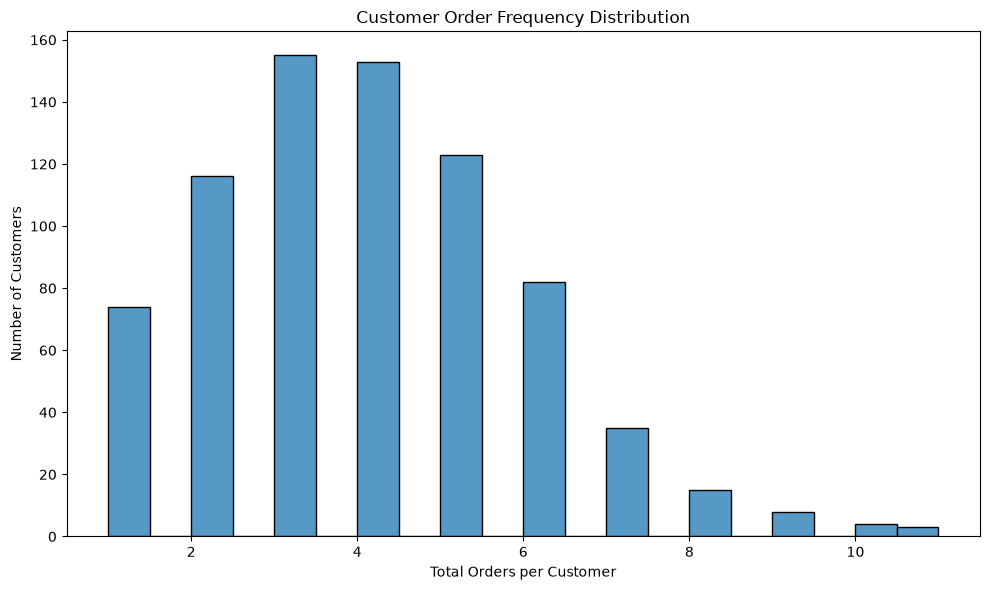

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=customer_summary,
    x="Customer_Total_Orders",
    bins=20,
    kde=False
)

plt.title("Customer Order Frequency Distribution")
plt.xlabel("Total Orders per Customer")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save chart
plt.savefig(
    "../Images/customer_order_frequency_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Export Analysis Outputs

Export cleaned and summary datasets for reporting, validation, and portfolio use.

In [34]:
# Export cleaned merged dataset
df.to_csv(
    "../Output/flagship_cleaned_merged_data.csv",
    index=False
)

# Export customer summary
customer_summary.to_csv(
    "../Output/customer_summary.csv",
    index=False
)

# Export monthly revenue summary
monthly_revenue.to_csv(
    "../Output/monthly_revenue_summary.csv",
    index=False
)

print("Output files exported successfully.")

Output files exported successfully.


## Key Python Insights

### Observation 1
Monthly revenue trend shows how business performance changes over time.

### Observation 2
Customer revenue distribution highlights whether revenue is concentrated among a smaller group of customers.

### Observation 3
Repeat vs one-time customer analysis helps evaluate retention behavior.

### Observation 4
Category-level profit margin comparison shows which categories are more efficient at generating profit.

### Observation 5
Discount vs profit and revenue vs profit analysis helps understand profitability patterns.